## 모듈 불러오기

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as stats
import seaborn as sns
import numpy as np
import platform
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, recall_score,precision_score, f1_score, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import optuna
import shap

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

# 출력 짤림 방지
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [20]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [21]:
# 전처리용 데이터프레임 생성
pre = df.copy()

In [22]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_DI'].dt.year - pre['YoB']

conditions = [
    pre['age'] >= 60,
    pre['age'] >= 50,
    pre['age'] >= 40,
    pre['age'] >= 30,
    pre['age'] >= 20,
]

choices = ['60s+', '50s', '40s', '30s', '20s']

pre['age_segment'] = np.select(conditions, choices, default='under 20')

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'Certified',
        'Explored',
        'Viewed',
        'Registered'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents', 
    'ndays_act', 
    'nplay_video', 
    'last_event_DI', 
    'age', 
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)
    

# 학습 기간 (duration) 컬럼 생성
pre['duration'] = (pre['last_event_DI'] - pre['start_time_DI']).dt.days.astype(int, errors='ignore')

In [23]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['LoE_DI'] = pre['LoE_DI'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre['nchapters'] = pre[pre['step']=='Registered']['nchapters'].fillna(0)

# 총 이벤트 발생 수 결측치(nevent) : registered 단계일 때 0으로 대체
pre['nevents'] = pre[pre['step']=='Registered']['nevents'].fillna(0)

# 활성 일수 결측치(ndays_act) : 0으로 대체
pre['ndays_act'] = pre['ndays_act'].fillna(0)

# 영상재생횟수(nplay_video) 결측치 : 논의중

# 마지막 이벤트 발생일 (last_event_DI) : 논의중

# 나이 (age) 결측치 : 논의중

# 성적(grade) 결측치 : 논의중




In [24]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] < 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# nchapters가 0인 viewed, explored, certified 행 제거
nchapter_mask = (pre['step'].isin(['Certified', 'Viewed', 'Explored'])) & (pre['nchapters']==0)
pre = pre[~nchapter_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

print('행 제거 작업 시작 후:')
print(pre.shape)

행 제거 작업 시작 전:
(641138, 32)


C:\Users\gmltk\AppData\Local\Temp\ipykernel_532704\2960777977.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 시작 후:
(355438, 32)


In [25]:
pre.isna().sum()

index                      0
course_id                  0
userid_DI                  0
registered                 0
viewed                     0
explored                   0
certified                  0
final_cc_cname_DI          0
LoE_DI                     0
YoB                    58978
gender                     0
grade                  31397
start_time_DI              0
last_event_DI          29858
nevents               235209
ndays_act                  0
nplay_video           174389
nchapters             235209
nforum_posts               0
roles                 355438
incomplete_flag       355438
age                    58978
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_DI_flag         0
age_flag                   0
grade_flag                 0
duration               29858
dtype: int64

In [26]:
# 컬럼 제거
pre = pre.drop(columns=['index', 'roles', 'YoB', 'registered', 'viewed', 'explored', 'start_time_DI', 'last_event_DI', 'userid_DI', 'age', 'step','grade', 'incomplete_flag', 'nplay_video', 'nchapters', 'nevents', 'duration'])

In [27]:
# 결측치 개수, 비율
display(pd.DataFrame({
    'bf_sum': df.isna().sum(),
    'bf_ratio': df.isna().mean() * 100,
    'af_sum': pre.isna().sum(),
    'af_ratio': pre.isna().mean() * 100
}).sort_values('bf_ratio', ascending=False).reset_index())

,index,bf_sum,bf_ratio,af_sum,af_ratio
0,roles,641138.0,100.000000,NaN,NaN
1,incomplete_flag,540977.0,84.377622,NaN,NaN
2,nplay_video,457530.0,71.362172,NaN,NaN
3,nchapters,258753.0,40.358394,NaN,NaN
4,nevents,199151.0,31.062111,NaN,NaN
5,last_event_DI,178954.0,27.911932,NaN,NaN
6,ndays_act,162743.0,25.383459,0.0,0.0
7,LoE_DI,106008.0,16.534350,0.0,0.0
8,YoB,96605.0,15.067739,NaN,NaN
9,gender,86806.0,13.539363,0.0,0.0


In [10]:
# 머러 시작
# test, train 분리
y = pre['certified'].astype(int)
X = pre.drop(columns=['certified']).copy()

# 범주형 컬럼
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
cat_idx = [X.columns.get_loc(c) for c in cat_cols]
num_cols = X.select_dtypes(include='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42, stratify=y
)

In [ ]:
# 1. train / valid 분리

# Optuna 내부 평가용 validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

cat_idx_tr = [X_tr.columns.get_loc(col) for col in cat_cols]

# 2. Optuna objective 함수

def objective(trial):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",   # CatBoost 내부 평가도 PR-AUC 기준
        "random_seed": 42,
        "verbose": 0,
        "auto_class_weights": "Balanced",

        # 튜닝 대상
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "depth": trial.suggest_int("depth", 12, 16),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_tr, y_tr,
        cat_features=cat_idx_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]

    # sklearn PR-AUC
    pr_auc = average_precision_score(y_val, y_val_proba)

    return pr_auc


# 3. Optuna 실행

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n=== Best Trial ===")
print("Best PR-AUC:", study.best_value)
print("Best Params:")
print(study.best_params)


# 4. 최적 파라미터로 전체 train 학습

best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced"
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 5. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test Performance ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

[I 2026-03-23 10:28:44,072] A new study created in memory with name: no-name-1c722a87-7586-4832-93bc-f56fc29a7d69
Best trial: 0. Best value: 0.927924:   3%|▎         | 1/30 [02:38<1:16:46, 158.85s/it]

[I 2026-03-23 10:31:22,922] Trial 0 finished with value: 0.9279243809794921 and parameters: {'iterations': 421, 'depth': 8, 'learning_rate': 0.04806063133599117, 'l2_leaf_reg': 2.3808224136125764, 'min_data_in_leaf': 26, 'subsample': 0.9747485415119697}. Best is trial 0 with value: 0.9279243809794921.


Best trial: 0. Best value: 0.927924:   7%|▋         | 2/30 [06:11<1:28:56, 190.58s/it]

[I 2026-03-23 10:34:55,707] Trial 1 finished with value: 0.9246664781622571 and parameters: {'iterations': 678, 'depth': 8, 'learning_rate': 0.014925637723728607, 'l2_leaf_reg': 1.2723851032643878, 'min_data_in_leaf': 46, 'subsample': 0.6206833901551324}. Best is trial 0 with value: 0.9279243809794921.


Best trial: 0. Best value: 0.927924:  10%|█         | 3/30 [08:23<1:13:40, 163.72s/it]

...

[I 2026-03-23 12:47:43,008] Trial 27 finished with value: 0.9286286025457233 and parameters: {'iterations': 301, 'depth': 12, 'learning_rate': 0.035832205577886765, 'l2_leaf_reg': 1.4392757147293778, 'min_data_in_leaf': 10, 'subsample': 0.7148240743852929}. Best is trial 19 with value: 0.9308400730091485.


Best trial: 19. Best value: 0.93084:  97%|█████████▋| 29/30 [2:23:23<04:54, 294.40s/it]

[I 2026-03-23 12:52:07,312] Trial 28 finished with value: 0.9302247746898038 and parameters: {'iterations': 464, 'depth': 11, 'learning_rate': 0.045500038488045916, 'l2_leaf_reg': 1.166473660876735, 'min_data_in_leaf': 23, 'subsample': 0.6311768224948567}. Best is trial 19 with value: 0.9308400730091485.


Best trial: 19. Best value: 0.93084: 100%|██████████| 30/30 [2:30:38<00:00, 301.29s/it]


[I 2026-03-23 12:59:22,882] Trial 29 finished with value: 0.9300091596527872 and parameters: {'iterations': 589, 'depth': 12, 'learning_rate': 0.025222078105627915, 'l2_leaf_reg': 2.2508341027388954, 'min_data_in_leaf': 5, 'subsample': 0.821509775682953}. Best is trial 19 with value: 0.9308400730091485.

=== Best Trial ===
Best PR-AUC: 0.9308400730091485
Best Params:
{'iterations': 1000, 'depth': 12, 'learning_rate': 0.03688485345853623, 'l2_leaf_reg': 1.0596783600864867, 'min_data_in_leaf': 8, 'subsample': 0.7694568297709484}
0:	learn: 0.9873610	test: 0.9884228	best: 0.9884228 (0)	total: 680ms	remaining: 11m 19s
100:	learn: 0.9973777	test: 0.9967751	best: 0.9967751 (100)	total: 1m 23s	remaining: 12m 23s
200:	learn: 0.9979172	test: 0.9969270	best: 0.9969270 (200)	total: 2m 42s	remaining: 10m 45s
300:	learn: 0.9982526	test: 0.9969871	best: 0.9969871 (300)	total: 3m 55s	remaining: 9m 7s
400:	learn: 0.9985346	test: 0.9969998	best: 0.9970049 (379)	total: 5m 20s	remaining: 7m 58s
500:	learn

In [25]:
#{'iterations': 1000, 'depth': 12, 'learning_rate': 0.03688485345853623, 'l2_leaf_reg': 1.0596783600864867, 'min_data_in_leaf': 8, 'subsample': 0.7694568297709484}
# 6. 최적 파라미터로 전체 train 학습

# best_params = study.best_params.copy()

final_model = CatBoostClassifier(
    # **best_param,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced",
    max_depth=7,
    iterations=358,
    learning_rate=0.05459690286945743,
    l2_leaf_reg=1.5080143762878997,
    min_data_in_leaf=14,
    subsample=0.9672172477416252
)

final_model.fit(
    X_train, y_train,
    cat_features=cat_idx,
    eval_set=(X_test, y_test),   # 최종 확인용
    use_best_model=True
)


# 7. 테스트 평가

y_pred = final_model.predict(X_test)
y_pred = np.array(y_pred).astype(int).ravel()

y_proba = final_model.predict_proba(X_test)[:, 1]

print("\n=== Test 데이터 모델 성능 ===")
print(f"PR-AUC   : {average_precision_score(y_test, y_proba):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

0:	learn: 0.9809454	test: 0.9816872	best: 0.9816872 (0)	total: 424ms	remaining: 2m 31s
100:	learn: 0.9965680	test: 0.9965208	best: 0.9965208 (100)	total: 44s	remaining: 1m 51s
200:	learn: 0.9969555	test: 0.9967875	best: 0.9967875 (200)	total: 1m 22s	remaining: 1m 4s
300:	learn: 0.9971317	test: 0.9968784	best: 0.9968784 (300)	total: 1m 58s	remaining: 22.5s
357:	learn: 0.9972205	test: 0.9968915	best: 0.9968915 (351)	total: 2m 20s	remaining: 0us

bestTest = 0.9968915066
bestIteration = 351

Shrink model to first 352 iterations.

=== Test 데이터 모델 성능 ===
PR-AUC   : 0.9246
ROC-AUC  : 0.9978
Recall   : 0.9971
Precision: 0.7006
F1-score : 0.8230

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9999    0.9845    0.9922     86600
           1     0.7006    0.9971    0.8230      3142

    accuracy                         0.9850     89742
   macro avg     0.8502    0.9908    0.9076     89742
weighted avg     0.9894    0.9850    0.9862     8974

In [26]:
# 1 클래스일 확률
y_proba = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.001)

results = []
best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    precision = precision_score(y_test, y_pred_th, zero_division=0)
    recall = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)

    results.append({
        "threshold": th,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

result_df = pd.DataFrame(results)

print("최적 threshold:", best_threshold)
print("최적 F1:", best_f1)

display(result_df.sort_values("f1", ascending=False).head(10))

최적 threshold: 0.9380000000000008
최적 F1: 0.8768750928263775


,threshold,precision,recall,f1
888,0.938,0.822055,0.939529,0.876875
892,0.942,0.825281,0.935073,0.876753
891,0.941,0.824684,0.935710,0.876696
885,0.935,0.819541,0.942393,0.876684
887,0.937,0.820833,0.940484,0.876594
884,0.934,0.818734,0.943030,0.876498
883,0.933,0.818157,0.943666,0.876441
886,0.936,0.820022,0.941120,0.876408
882,0.932,0.817181,0.944621,0.876292
890,0.940,0.823398,0.936346,0.876247


In [27]:
# 적용 후 성능 확인

best_threshold = 0.934
y_pred_opt = (y_proba >= best_threshold).astype(int)


print("=== 최적 threshold 적용 후 성능 ===")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_proba):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_opt):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_opt):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_opt, digits=4))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_opt))

=== 최적 threshold 적용 후 성능 ===
Threshold : 0.93
Accuracy  : 0.9907
ROC-AUC   : 0.9978
PR-AUC    : 0.9246
Precision : 0.8187
Recall    : 0.9430
F1-score  : 0.8765

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9979    0.9924    0.9952     86600
           1     0.8187    0.9430    0.8765      3142

    accuracy                         0.9907     89742
   macro avg     0.9083    0.9677    0.9358     89742
weighted avg     0.9916    0.9907    0.9910     89742


=== Confusion Matrix ===
[[85944   656]
 [  179  2963]]


<Figure size 1200x700 with 0 Axes>

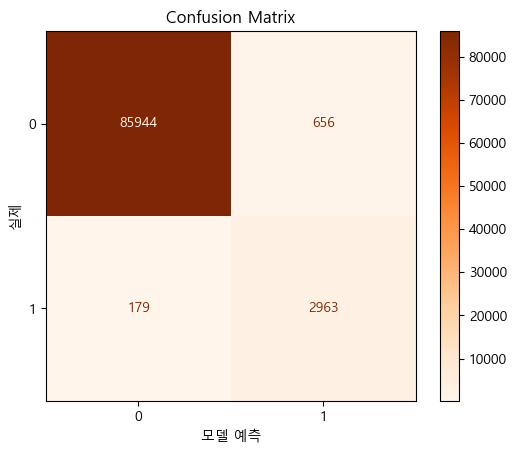

In [28]:
# 혼동행렬 출력
plt.figure(figsize=(12,7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_opt, cmap='Oranges', values_format="d")
plt.title("Confusion Matrix")
plt.xlabel('모델 예측')
plt.ylabel('실제')
plt.show()

In [29]:
# shap

# shap explainer 생성
explainer = shap.TreeExplainer(final_model)

# test 데이터에 대한 shap value 계산
shap_values = explainer.shap_values(X_test)

# 이진분류일 때
# 어떤 환경에서는 list가 아니라 바로 array로 나올 수도 있음
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# shop
print(np.array(shap_values_class1).shape)

(89742, 12)


c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gmltk\Desktop\스파르타 내일배움\004_projects\projects\HOHO_Project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


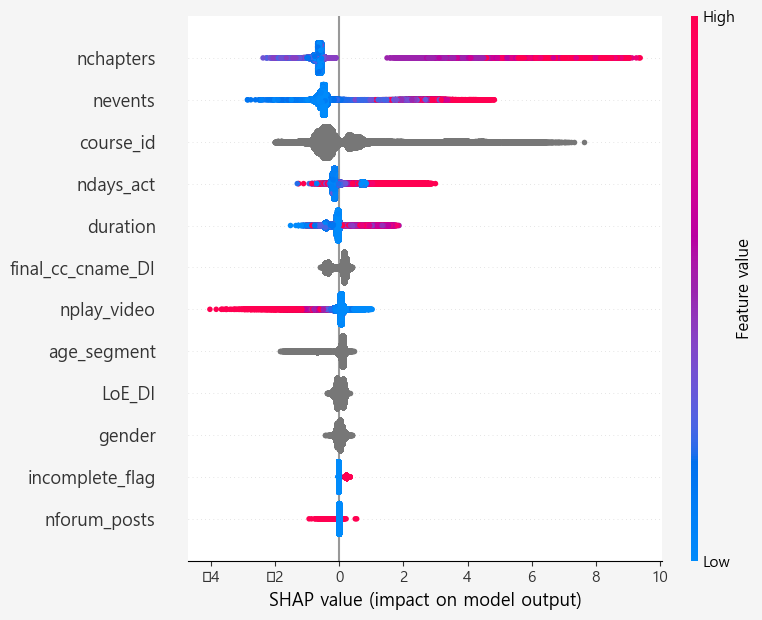

In [30]:
plt.figure(facecolor='whitesmoke')
shap.summary_plot(shap_values_class1, X_test)

In [31]:
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

display(shap_importance.head(20))

,feature,mean_abs_shap
7,nchapters,1.218328
4,nevents,0.803946
0,course_id,0.716148
5,ndays_act,0.290718
11,duration,0.246570
1,final_cc_cname_DI,0.219831
6,nplay_video,0.173246
10,age_segment,0.149382
2,LoE_DI,0.085731
3,gender,0.064243
